# Mushrooms

In this quesetion we are going to be investigating mushrooms and trying to predict whether they are poisonous or not. Before this, I made sure to taste all the mushrooms and test them myself to see if they were poisonous so after training this model, perhaps I no longer need to test if the mushrooms are poisonous. Maybe we will even discover some common patterns between all poisonous and non-poisonous mushrooms.

We will need the following:

## Understanding Our Data

In `mushrooms.csv`, we have many features that describe the parts and qualities of a mushroom such as its coloring, size, and rarity. 

Let's get set up first.

In [ ]:
import plotly.express as px
import pandas as pd
import numpy as np
import plotly.io as pio
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('mushrooms.csv')

Currently, our data is hard to interpret as characters. Let's use label encoder to visualize all this data numerically.

In [ ]:
Encoder_Data = LabelEncoder()
for col in df.columns: df[col] = Encoder_Data.fit_transform(df[col])

corr_matrix = df.corr()
fig = px.imshow(
    corr_matrix,
    aspect="auto",
    color_continuous_scale="RdBu_r",
    title="Correlation Matrix Heatmap"
)

fig.update_layout(height=900)
pio.renderers.default = "browser"
pio.show(fig)

Next lets create a histogram for all features to see the different categorizations.

In [ ]:
for col in df.columns:
    fig = px.histogram(
        df,
        x=col,
        title=f"Histogram of {col}",
        color=col
    )
    pio.renderers.default = "browser"
    pio.show(fig)

Luckily we don't have to worry about any outliers because we have non-numerical data. It should be noted though that some features will have '?' signs for missing data. This is already accounted for in our earlier implementation because the data wasn't loading. By using `.unique` we can quickly see all unique entries within a row and find this. We should also know that many mushrooms do not have a `stalk-root` which makes it disproportionately small to other features.

The main characteristic of this data set we need to watch out for is the amount of `NaN` values there are and what they mean. We shouldn't drop all `NaN`values because not all species of mushrooms necessarily have the same parts, and we can see this as dropping na will cause most of our data to not be preserved. Let's reload our data with this in mind.

That being said there must be a reasonable explanation why so many mushrooms don't have a `stalk-root`. Perhaps the `NaN` isn't just noise and can give us some patterns to investigate between the other features.

Still though, lets clean our data as discussed.

In [ ]:
df = pd.read_csv('mushrooms.csv')
df.replace('?', np.nan, inplace=True)
df = df.fillna('missing')

Before doing any analysis let's see if our data is balanced.

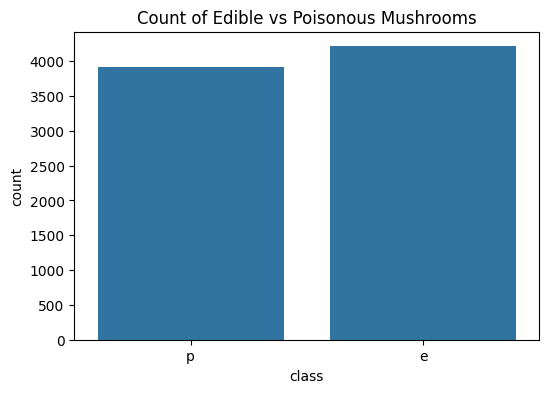

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='class')
plt.title("Count of Edible vs Poisonous Mushrooms")
plt.show()

The data set is balanced as they are relatively similar in count. This means that we do not need to weigh our data and that any bias from the edible class will not affect the overall result that much if at all.

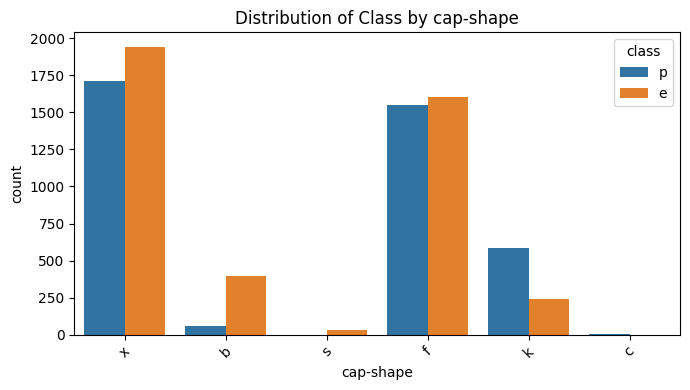

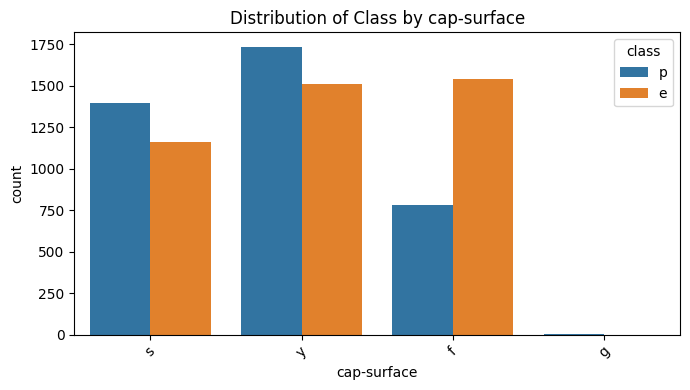

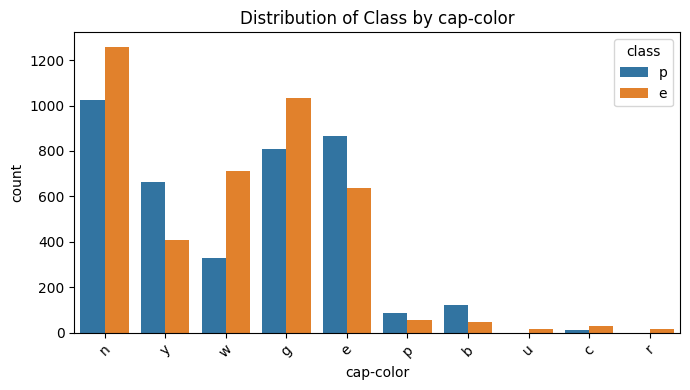

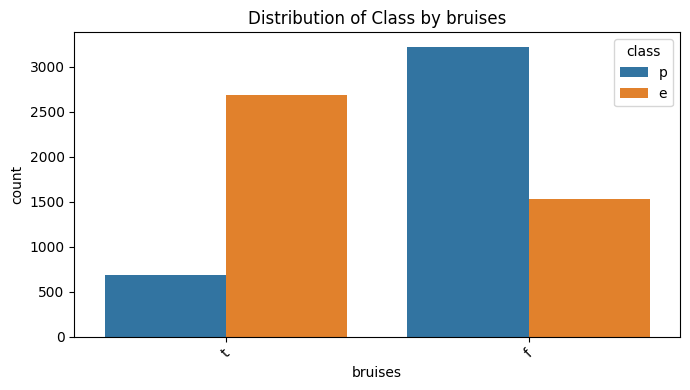

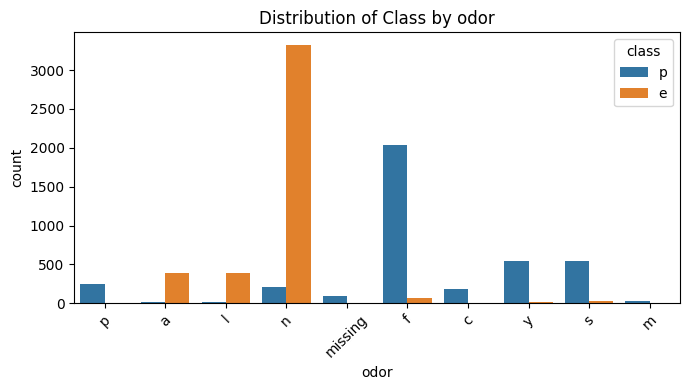

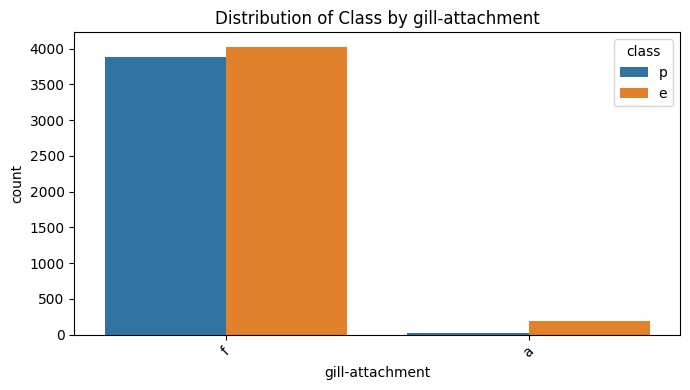

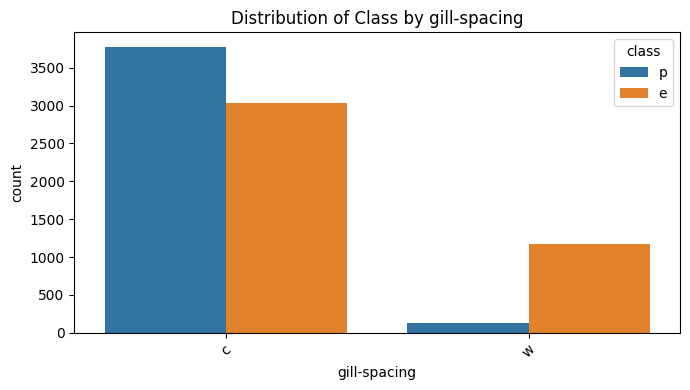

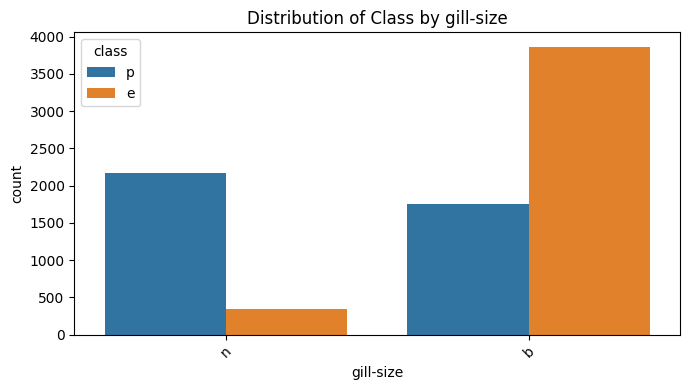

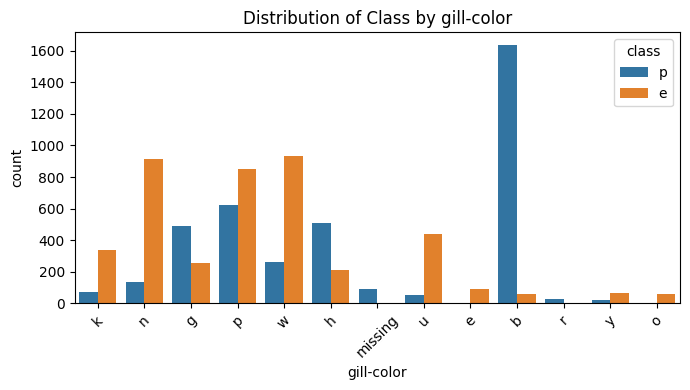

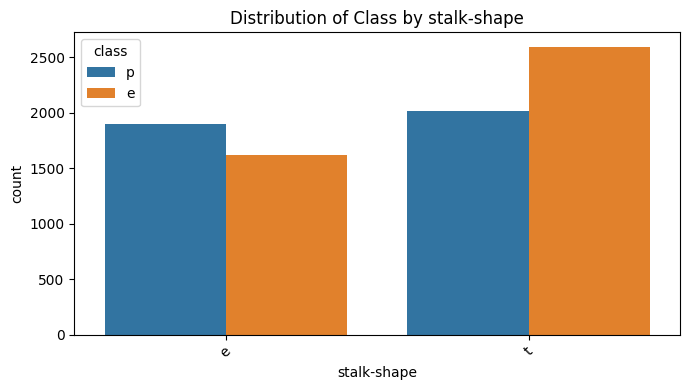

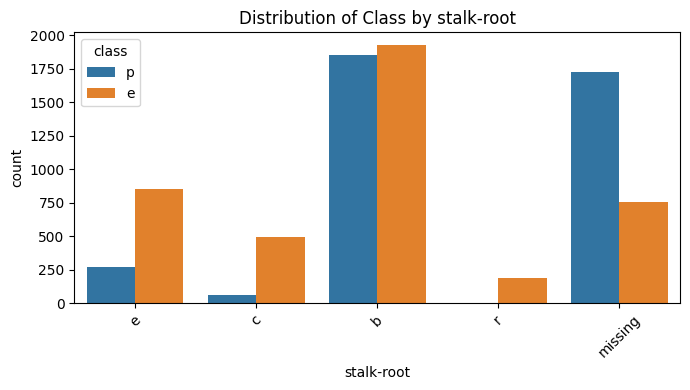

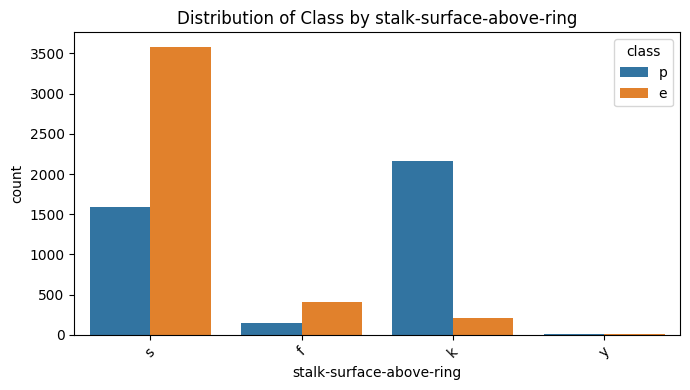

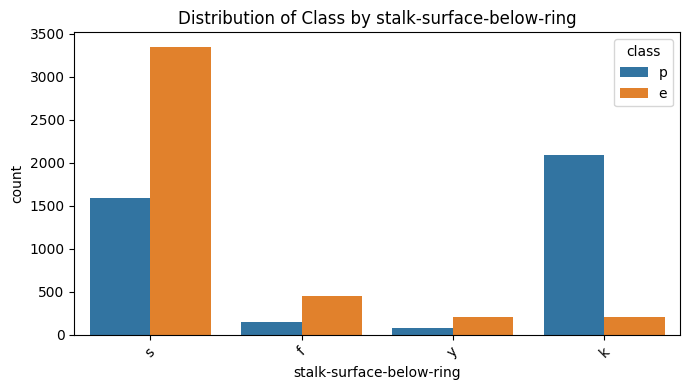

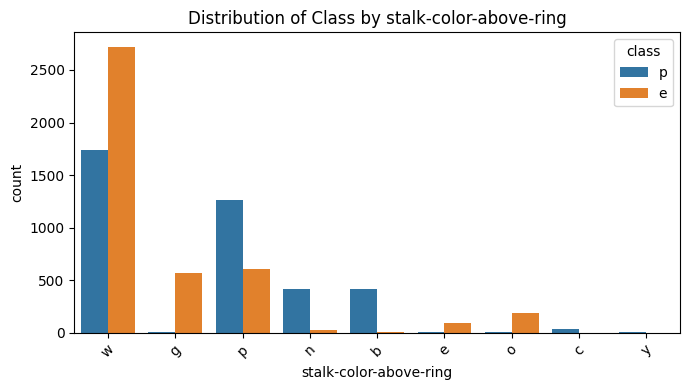

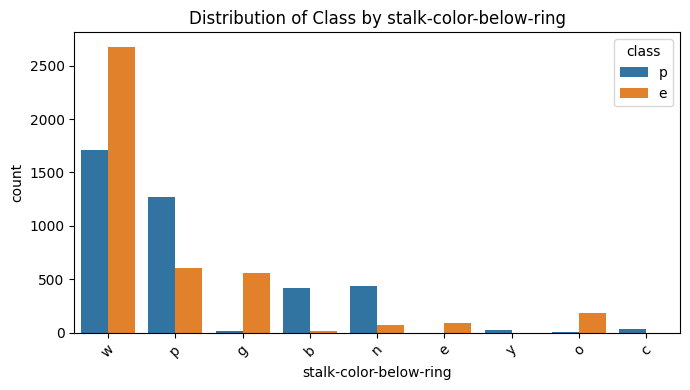

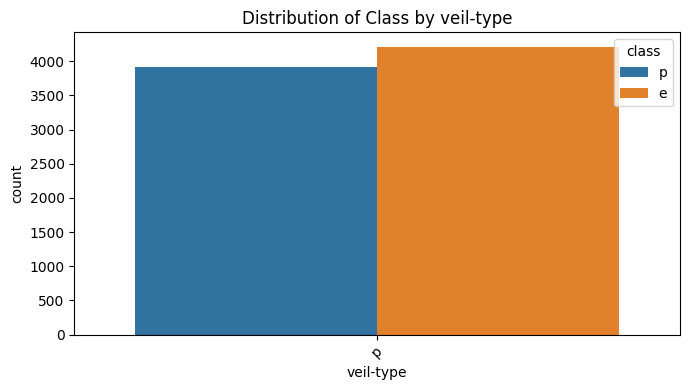

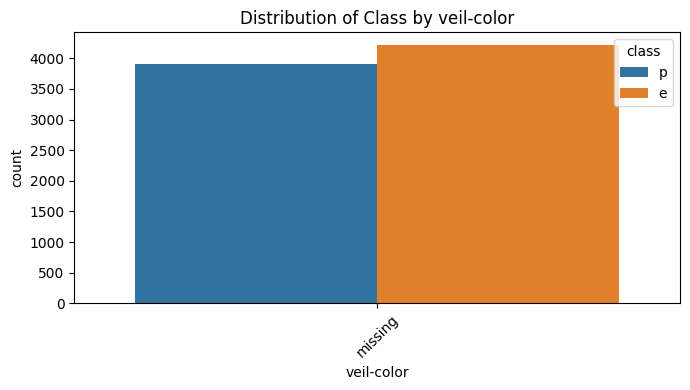

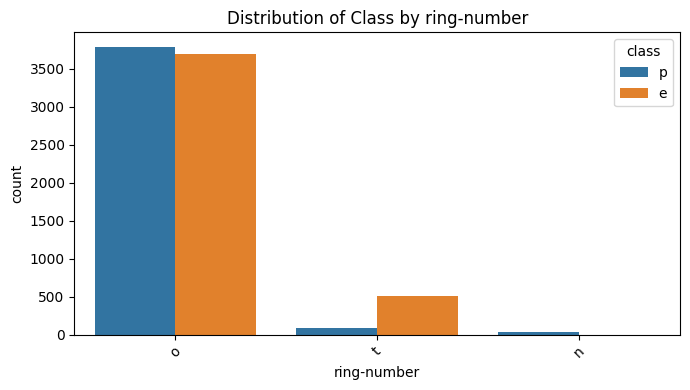

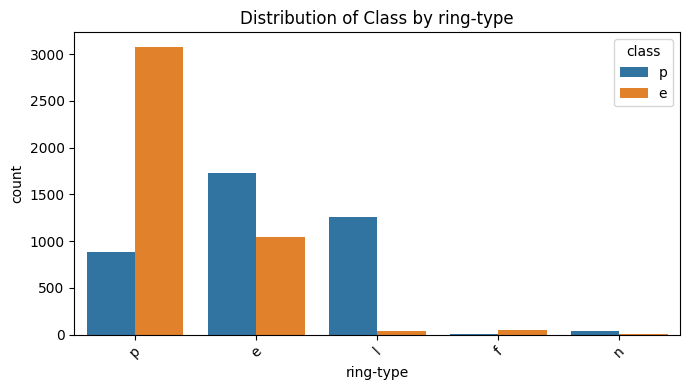

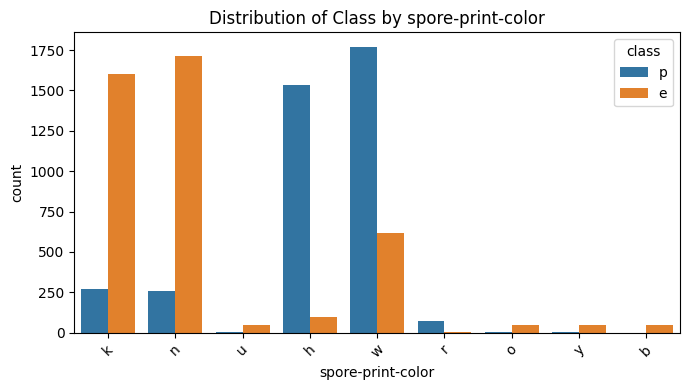

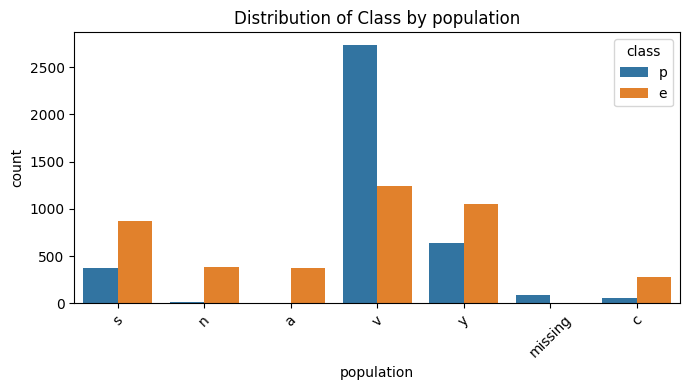

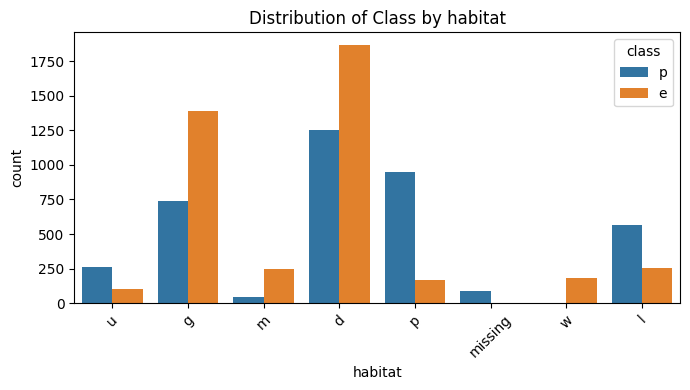

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

features = df.columns.drop('class')

for feature in features:
    plt.figure(figsize=(7,4))
    sns.countplot(data=df, x=feature, hue='class')
    plt.title(f"Distribution of Class by {feature}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

There are two notable graphs that we should investigate. `Odor` categories almost exclusively correspond to poisonous or edible mushrooms, with clear separation in most classes. Similarly, `gill_size` also has some very noticeable separations for poisonous and edible mushrooms. 

We theorized earlier that the `NaN`/`missing` values may describe the relationship between some of our features with poisonous and edible mushrooms. We should retain this feature value because `missing` values are present in almost every feature so it might be an additional discriminatory variable we can use for classification.

## Building Our Model

Let's construct our feature matrix and target variables. Let 0 denote poisonous and 1 denote edible in the matrix.

In [ ]:
X = df.drop('class', axis=1)
y = df['class']
X = pd.get_dummies(X)

Encoder_Data = LabelEncoder()
y = Encoder_Data.fit_transform(y)

The Gini Index is a measure of node purity in a decision tree classifier. From splitting our data recursively, eventually we will get a node that contains data that can no longer be split by class. For example, if I have 8 collumns with an even split of edible and poisonous. If I split all 8 collumns perfectly into poisonous and edible, both of the child nodes would be considered pure. Ideally, our Gini Index should be 0, and as our data is more mixed, the further it goes from 0. 

This is particularly useful because we want to make the least number of splits by making splits that make a larger impact on the data as a whole. With an index to base our splits off of, we can easily automate this process of choosing the best split.

Let's train our model using `DecisionTreeClassifier` on both our training and test sets using the minimum number of leaf samples and then again with the largest tree depth we can create.

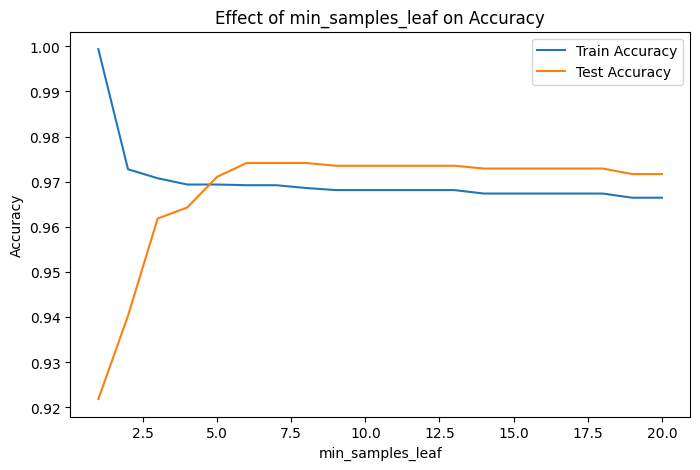

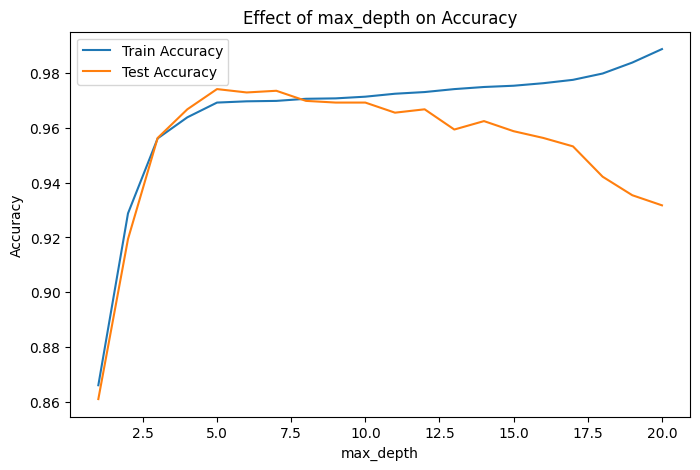

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

def classifierkl(X_train, X_test, y_train, y_test, param_name, range):
    
    train_acc = []
    test_acc = []
    
    for value in range:
        clf = DecisionTreeClassifier(criterion='gini', random_state=42,**{param_name: value})
        clf.fit(X_train, y_train)
        
        # Predictions
        y_train_pred = clf.predict(X_train)
        y_test_pred = clf.predict(X_test)
        
        train_accuracy = np.sum(y_train == y_train_pred) / len(y_train)
        test_accuracy = np.sum(y_test == y_test_pred) / len(y_test)
        
        train_acc.append(train_accuracy)
        test_acc.append(test_accuracy)

    plt.figure(figsize=(8,5))
    plt.plot(range, train_acc, label='Train Accuracy')
    plt.plot(range, test_acc, label='Test Accuracy')
    plt.xlabel(param_name)
    plt.ylabel("Accuracy")
    plt.title(f"Effect of {param_name} on Accuracy")
    plt.legend()
    plt.show()
    
    return train_acc, test_acc

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = DecisionTreeClassifier(criterion='gini', random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

values = range(1, 21)

train_acc_leaf, test_acc_leaf = classifierkl(X_train, X_test, y_train, y_test,"min_samples_leaf",values)
train_acc_depth, test_acc_depth = classifierkl(X_train, X_test, y_train, y_test,"max_depth",values)

In the first plot, we can see that increasing leaf size will lower the accuracy by a small margin, however it is best not to use a small leaf size to avoid overfitting our data. Conversely, we don't want a large leaf size either as this will depreciate our accuracy in the long run so ideally we use a leaf size where both our training and test set accuracy are relatively similar. It seems that 5.0-7.5 is a promissing range however, these leaf sizes may still be too small.

As for our max depth, it is really easy to see the ideal range. We want the area with high accuracy on our training and test set and the best range for our maximum depth is around 5.0-7.5. While our training accuracy increases with larger depth, it begins to hinder our test accuracy due to overfitting. In the range 5.0 and 7.5, we can get the best of both worlds.

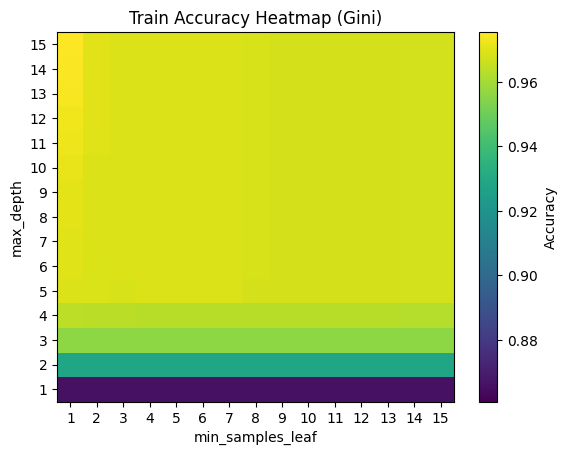

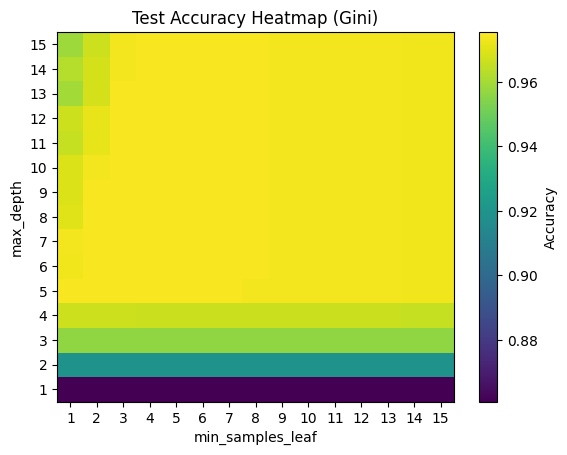

In [ ]:
depth_values = range(1, 16)
leaf_values = range(1, 16)

train_heatmap = np.zeros((len(depth_values), len(leaf_values)))
test_heatmap = np.zeros((len(depth_values), len(leaf_values)))

for i, depth in enumerate(depth_values):
    for j, leaf in enumerate(leaf_values):
        
        clf = DecisionTreeClassifier(
            criterion='gini',
            max_depth=depth,
            min_samples_leaf=leaf,
            random_state=42
        )
        
        clf.fit(X_train, y_train)
        
        y_train_pred = clf.predict(X_train)
        y_test_pred = clf.predict(X_test)
        
        # Manual accuracy
        train_acc = np.sum(y_train == y_train_pred) / len(y_train)
        test_acc = np.sum(y_test == y_test_pred) / len(y_test)
        
        train_heatmap[i, j] = train_acc
        test_heatmap[i, j] = test_acc
vmin = min(train_heatmap.min(), test_heatmap.min())
vmax = max(train_heatmap.max(), test_heatmap.max())

plt.figure()
plt.imshow(train_heatmap, origin='lower', aspect='auto',
        vmin=vmin, vmax=vmax)
plt.colorbar(label="Accuracy")
plt.xticks(range(len(leaf_values)), leaf_values)
plt.yticks(range(len(depth_values)), depth_values)
plt.xlabel("min_samples_leaf")
plt.ylabel("max_depth")
plt.title("Train Accuracy Heatmap (Gini)")
plt.show()


plt.figure()
plt.imshow(test_heatmap, origin='lower', aspect='auto',
        vmin=vmin, vmax=vmax)
plt.colorbar(label="Accuracy")
plt.xticks(range(len(leaf_values)), leaf_values)
plt.yticks(range(len(depth_values)), depth_values)
plt.xlabel("min_samples_leaf")
plt.ylabel("max_depth")
plt.title("Test Accuracy Heatmap (Gini)")
plt.show()


By creating a heatmap of these features we notice that our training set gets greener the higher the accuracy and leaf size. The same is true for our test accuracy except the center of the heatmap adopts a more yellowish color. As we observe depreciation in color just like we do in the line plot for our training set as well as a yellow center representing high accuracy in both our max depth plots. 

Visually, the line plot is much easier to look at for spotting differences so our interpretation earlier remains unchanged. Let's look at what our decision tree might look like.

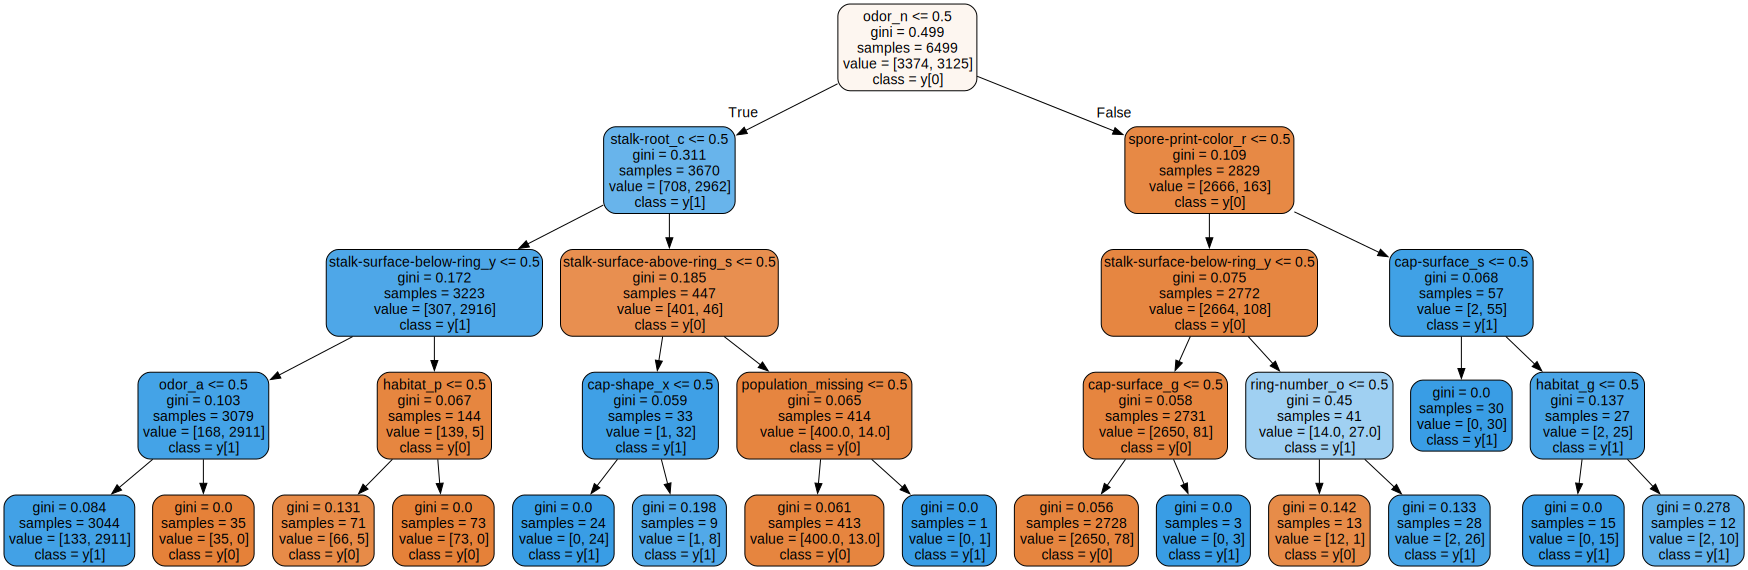

In [ ]:
from sklearn.tree import export_graphviz
import graphviz
clf = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42)

clf.fit(X_train, y_train)

dot_data = export_graphviz(
    clf,
    out_file=None,
    feature_names=X_train.columns,
    class_names=True,
    filled=True,
    rounded=True
)

graph = graphviz.Source(dot_data)
graph

The root node has the most important role in the decision tree, with each subsequent layer being less and less effective. Odor is the strongest feature as it appears multiple times so it is undisputabely the `feature` that contributes the most to splitting the data up. The feature `stalk-surface-below-ring` is also a notable feature for it is the second feature we use to separate our data, meaning that it also has a notable contribution. After the third layer though, it is hard to say whether the features that appear have a large contribution on the overall data as at this point they are separating very small portions of data. While features such as `habitat` frequently, they don't separate as much data as the first two layers.

Let's see how an entropy splitting criteria looks like in comparison.

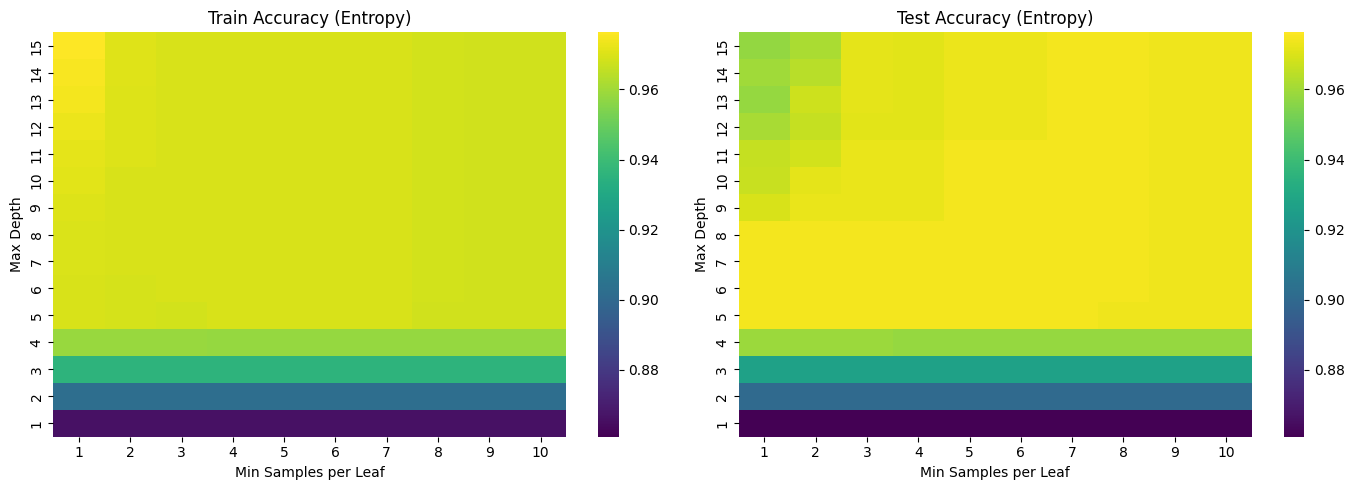

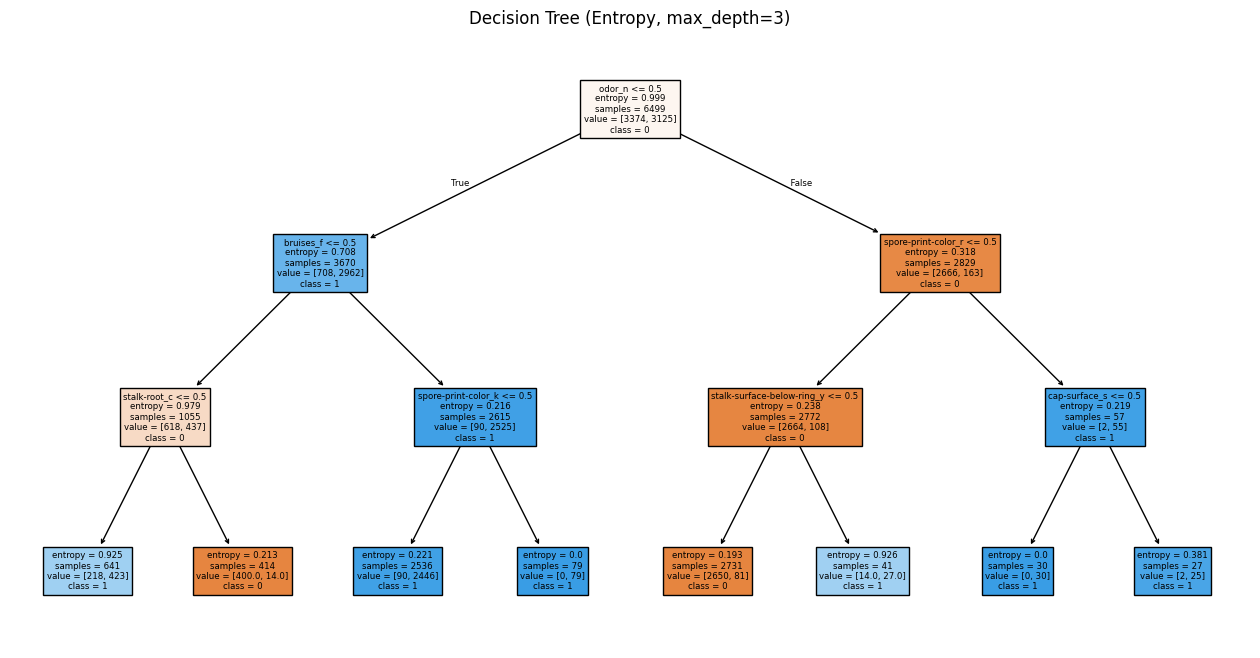

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
depths = range(1, 16)
leaves = range(1, 11)

train_scores = np.zeros((len(depths), len(leaves)))
test_scores = np.zeros((len(depths), len(leaves)))

for i, d in enumerate(depths):
    for j, l in enumerate(leaves):

        model = DecisionTreeClassifier(
            max_depth=d,
            min_samples_leaf=l,
            criterion='entropy',
            random_state=42
        )

        model.fit(X_train, y_train)

        # Manual accuracy calculation
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        train_scores[i, j] = np.mean(y_train == y_train_pred)
        test_scores[i, j] = np.mean(y_test == y_test_pred)

# Shared color scale
vmin = min(train_scores.min(), test_scores.min())
vmax = max(train_scores.max(), test_scores.max())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(train_scores,
            xticklabels=leaves,
            yticklabels=depths,
            vmin=vmin,
            vmax=vmax,
            cmap="viridis",
            ax=axes[0])

axes[0].set_title("Train Accuracy (Entropy)")
axes[0].set_xlabel("Min Samples per Leaf")
axes[0].set_ylabel("Max Depth")
axes[0].invert_yaxis()

sns.heatmap(test_scores,
            xticklabels=leaves,
            yticklabels=depths,
            vmin=vmin,
            vmax=vmax,
            cmap="viridis",
            ax=axes[1])

axes[1].set_title("Test Accuracy (Entropy)")
axes[1].set_xlabel("Min Samples per Leaf")
axes[1].set_ylabel("Max Depth")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


# Limited-depth entropy tree
model_small = DecisionTreeClassifier(
    max_depth=3,
    criterion='entropy',
    random_state=42
)

model_small.fit(X_train, y_train)

plt.figure(figsize=(16, 8))
plot_tree(model_small,
          feature_names=X.columns,
          class_names=[str(c) for c in np.unique(y_train)],
          filled=True)

plt.title("Decision Tree (Entropy, max_depth=3)")
plt.show()

Entropy and Gini seem to have very similar to almost identical stats but with different splitting conditions. While this may warrant investigation, the overall depth stays the same which means that while different, our splitting conditions ultimately lead to similar accuracies. Let's see how a Random Forest classifier compares.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

depths = range(1, 16)
trees = [10, 50, 100, 200]

for criterion in ['gini', 'entropy']:

    print(f"\n--- Random Forest using {criterion.upper()} ---\n")

    train_scores = np.zeros((len(depths), len(trees)))
    test_scores = np.zeros((len(depths), len(trees)))

    for i, d in enumerate(depths):
        for j, t in enumerate(trees):

            model = RandomForestClassifier(
                n_estimators=t,
                max_depth=d,
                criterion=criterion,
                random_state=42,
                n_jobs=-1
            )

            model.fit(X_train, y_train)

            # Manual accuracy calculation
            y_train_pred = model.predict(X_train)
            y_test_pred = model.predict(X_test)

            train_scores[i, j] = np.mean(y_train == y_train_pred)
            test_scores[i, j] = np.mean(y_test == y_test_pred)

    vmin = min(train_scores.min(), test_scores.min())
    vmax = max(train_scores.max(), test_scores.max())

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(train_scores,
                xticklabels=trees,
                yticklabels=depths,
                vmin=vmin,
                vmax=vmax,
                cmap="viridis",
                ax=axes[0])

    axes[0].set_title(f"Train Accuracy (RF - {criterion})")
    axes[0].set_xlabel("Number of Trees")
    axes[0].set_ylabel("Max Depth")
    axes[0].invert_yaxis()

    sns.heatmap(test_scores,
                xticklabels=trees,
                yticklabels=depths,
                vmin=vmin,
                vmax=vmax,
                cmap="viridis",
                ax=axes[1])

    axes[1].set_title(f"Test Accuracy (RF - {criterion})")
    axes[1].set_xlabel("Number of Trees")
    axes[1].set_ylabel("Max Depth")
    axes[1].invert_yaxis()

    plt.tight_layout()
    plt.show()


--- Random Forest using GINI ---



KeyboardInterrupt: 

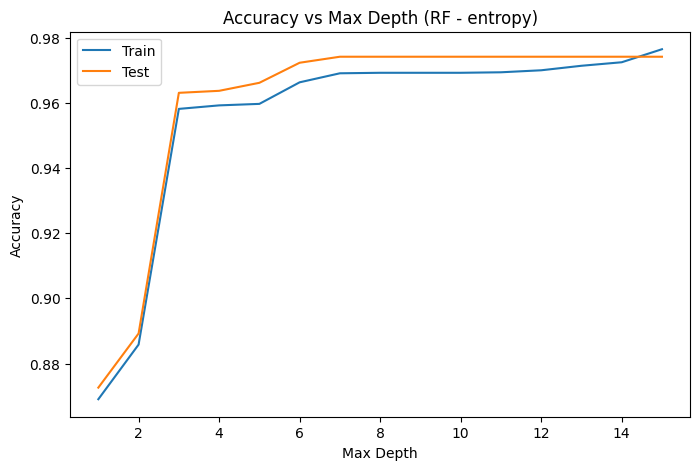

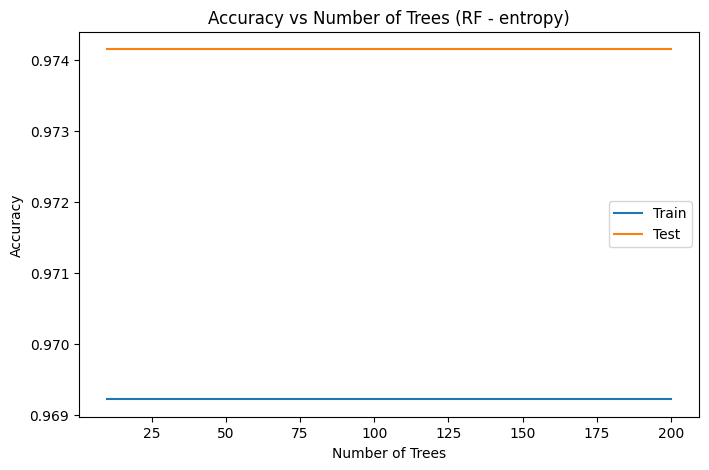

In [ ]:
fixed_trees = 100

train_acc_depth = []
test_acc_depth = []

for d in depths:
    model = RandomForestClassifier(
        n_estimators=fixed_trees,
        max_depth=d,
        criterion=criterion,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_acc_depth.append(np.mean(y_train == y_train_pred))
    test_acc_depth.append(np.mean(y_test == y_test_pred))

plt.figure(figsize=(8,5))
plt.plot(depths, train_acc_depth, label="Train")
plt.plot(depths, test_acc_depth, label="Test")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title(f"Accuracy vs Max Depth (RF - {criterion})")
plt.legend()
plt.show()


fixed_depth = 8

train_acc_trees = []
test_acc_trees = []

for t in trees:
    model = RandomForestClassifier(
        n_estimators=t,
        max_depth=fixed_depth,
        criterion=criterion,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_acc_trees.append(np.mean(y_train == y_train_pred))
    test_acc_trees.append(np.mean(y_test == y_test_pred))

plt.figure(figsize=(8,5))
plt.plot(trees, train_acc_trees, label="Train")
plt.plot(trees, test_acc_trees, label="Test")
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.title(f"Accuracy vs Number of Trees (RF - {criterion})")
plt.legend()
plt.show()

From the graphs above, we can make a few conclusions about how important number of trees is. In the Accuracy vs Number of Trees plot we see two horizontal lines. This shows that after a certain point, increasing the number of trees creates diminishing returns when it comes to computation power and results. As proven by the Accuracy vs Max Depth, our Accuracy really starts to plateau as we increase depth as well. Not only that, for both depth and number of trees, we may even be overfitting our data if we increase their value which is a cause for concern. 

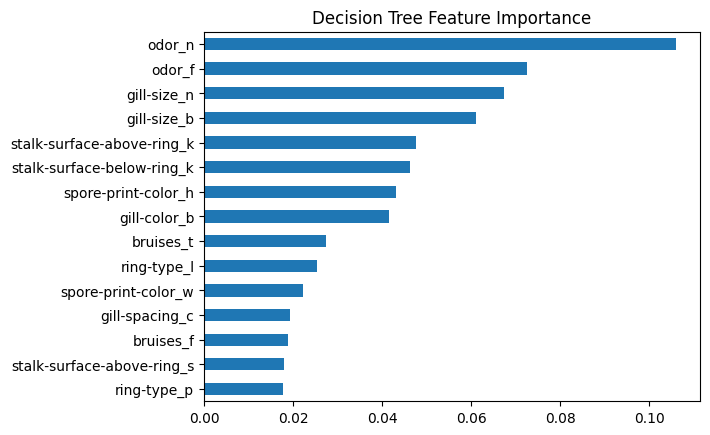

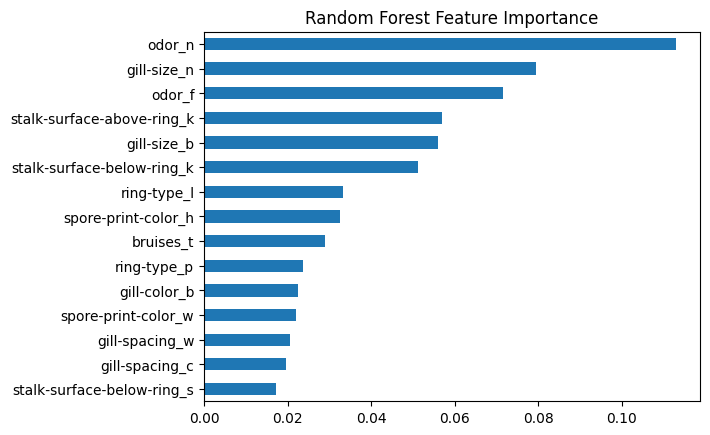

In [ ]:
dt_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure()
dt_importance.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Decision Tree Feature Importance")
plt.show()

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

rf_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure()
rf_importance.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance")
plt.show()

One thing that is clear is that `odor_n` is the undisputably most important feature when it comes to our classification with `odor_f` and `gill-size_n` occupying the top three in both methods. This is different than our earlier vizualizations during the decision tree portion of our analysis. We expected `stalk-surface-below-ring` to be the second best decision variable due to it separating the second largest portion of data, yet gill-size seems to be more important at classifying than it. 

This discovery actually lines up with our earlier hypothesis when understanding data. This contradiction is no coincidence and in fact, both can be true. What our data ultimately tells us is that feature importance does not necessarily correlate to good separation values. When separating between two classes, we need a feature that differentiates between classes the most, not one that categorizes them with the most minimal effort.

For example, lets say a `feature_1` can categorize your target variable but has many classes while `feature_2` does the same but has less classes in the feature. While `feature_1` is more accurate, it is terrible to split upon because it splits less evenely than `feature_2` which has less classes, making it more black and white, and therefore more divisible.

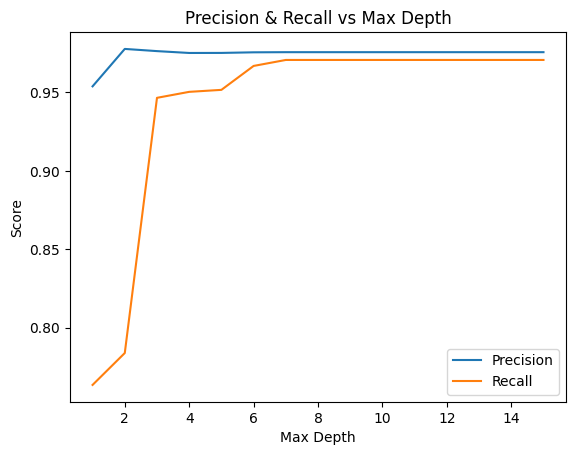

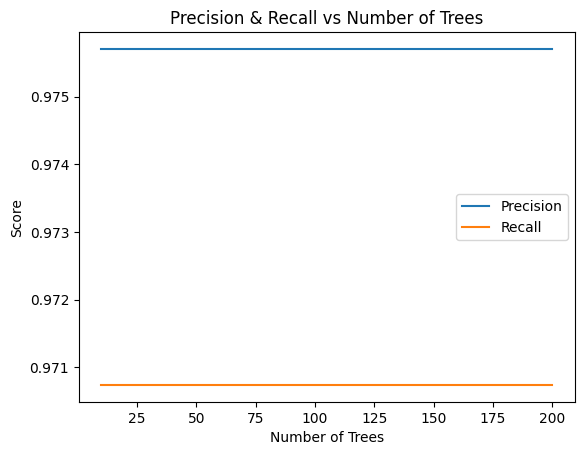

In [ ]:
precision_vs_depth = []
recall_vs_depth = []

precision_vs_trees = []
recall_vs_trees = []

depth_values = range(1, 16)
tree_values = [10, 50, 100, 200]

for depth in depth_values: 
    rf = RandomForestClassifier(n_estimators=100,max_depth=depth,random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    TP = np.sum((y_pred == 1) & (y_test == 1))
    FP = np.sum((y_pred == 1) & (y_test == 0))
    FN = np.sum((y_pred == 0) & (y_test == 1))

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0

    precision_vs_depth.append(precision)
    recall_vs_depth.append(recall)

for trees in tree_values:
    rf = RandomForestClassifier(n_estimators=trees,max_depth=10,random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    TP = np.sum((y_pred == 1) & (y_test == 1))
    FP = np.sum((y_pred == 1) & (y_test == 0))
    FN = np.sum((y_pred == 0) & (y_test == 1))

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0

    precision_vs_trees.append(precision)
    recall_vs_trees.append(recall)

plt.figure()
plt.plot(depth_values, precision_vs_depth, label="Precision")
plt.plot(depth_values, recall_vs_depth, label="Recall")
plt.xlabel("Max Depth")
plt.ylabel("Score")
plt.title("Precision & Recall vs Max Depth")
plt.legend()
plt.show()

plt.figure()
plt.plot(tree_values, precision_vs_trees, label="Precision")
plt.plot(tree_values, recall_vs_trees, label="Recall")
plt.xlabel("Number of Trees")
plt.ylabel("Score")
plt.title("Precision & Recall vs Number of Trees")
plt.legend()
plt.show()

Similarly to accuracy, we see that Precision and Recall also begin to plateau with increasing number of trees and further max depth, though it is important to know that our precision is always very high when it comes to any value of max depth. Again, our tradeoffs are around the same. How much computational power (depth) are we going to sacrifice for better performance? More trees and higher max depth give diminishing returns after a while or even stay the same. While number of trees doesn't seem to change at all between 25 to 200 trees we can confidently say that a tree depth of 6-8 is an ideal sweetspot where our model begins to plateau in performance while saving on computational resources.

## SVM Training

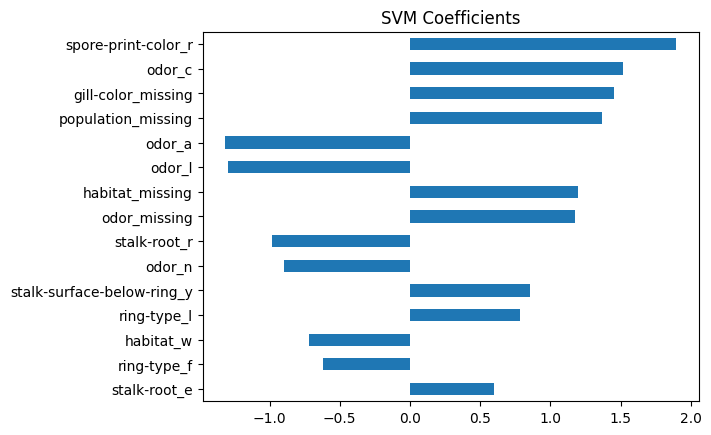

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

svm = LinearSVC(max_iter=5000)
svm.fit(X_train, y_train)

svm_coef = pd.Series(
    svm.coef_[0],
    index=X.columns
).sort_values(key=abs, ascending=False)

plt.figure()
svm_coef.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("SVM Coefficients")
plt.show()

Unlike our Decision Tree model our SVM model gives us negative values. In our SVM, positive coeffiicents correlate to poisonous while negative values correlate to edible. As predicted in all of our analysis, odor is one of the strongest classifiers for determining how edible a mushroom is with `odor_c`, `order_a`, and `order_l` taking up half of our top 6 most dramatic features. However, unlike our Decision Tree model, our important features are `spore-print-color_r`, `gill-color_missing`, and `population_missing` which connects all the way back to answer whether missing variables were important for analysis. In the case of SVM's, NaNs are a very important metric to use for classification. 

After all of our analysis, while order is the undisputable number one feature we can use to classify. The top 5 are always changing depending on which method of classification we use. Perhaps hinge loss will finally give us an agreement on what the other important features are.

In [ ]:
from sklearn.linear_model import SGDClassifier

sgd = SGDClassifier(loss='hinge', max_iter=5000, random_state=42)
sgd.fit(X_train, y_train)

y_pred_sgd = sgd.predict(X_test)

print(classification_report(y_test, y_pred_sgd))

              precision    recall  f1-score   support

           0       0.97      0.98      0.98       839
           1       0.98      0.97      0.97       786

    accuracy                           0.97      1625
   macro avg       0.97      0.97      0.97      1625
weighted avg       0.97      0.97      0.97      1625



SGD, or Stochastic Gradient Descent, actually has a very similar result as all of our previous methods. In practice this model is supposed to be a better classifier yet 'worse' models are performing better. This is simply due to the fact that our analysis in nature is binary (edible/poisonous) and so we do not need a complex model to solve a simple problem.

BUT ITS OKAY BECAUSE IM HAVING SO MUCH FUNFUNFUNFUNFUNFUN! IF I WASNT. WHY WOULD I BE LAUGHING RIGHT NOW HEEHEEHEEHEEHEEHEEHEEHEEHEEHEEHEEHEEHEEHEEHEE.

Anyway back on topic lets normalize/standardize our data.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

scaled_svm = make_pipeline(
    StandardScaler(),
    LinearSVC(max_iter=5000)
)

scaled_svm.fit(X_train, y_train)

print(classification_report(
    y_test,
    scaled_svm.predict(X_test)
))

              precision    recall  f1-score   support

           0       0.97      0.98      0.98       839
           1       0.98      0.97      0.97       786

    accuracy                           0.97      1625
   macro avg       0.97      0.97      0.97      1625
weighted avg       0.97      0.97      0.97      1625



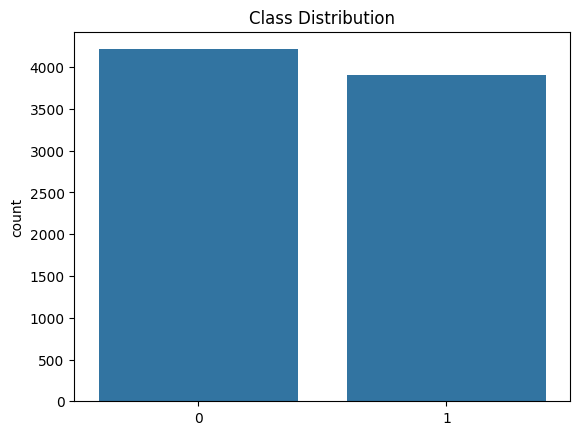

              precision    recall  f1-score   support

           0       0.97      0.98      0.97       839
           1       0.97      0.97      0.97       786

    accuracy                           0.97      1625
   macro avg       0.97      0.97      0.97      1625
weighted avg       0.97      0.97      0.97      1625



In [ ]:
sns.countplot(x=y)
plt.title("Class Distribution")
plt.show()

rf_balanced = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

rf_balanced.fit(X_train, y_train)

print(classification_report(
    y_test,
    rf_balanced.predict(X_test)
))

As hypothesised, class weighting has little to no affect on our model in any sense of computing performance. This indicates that our data is balanced.

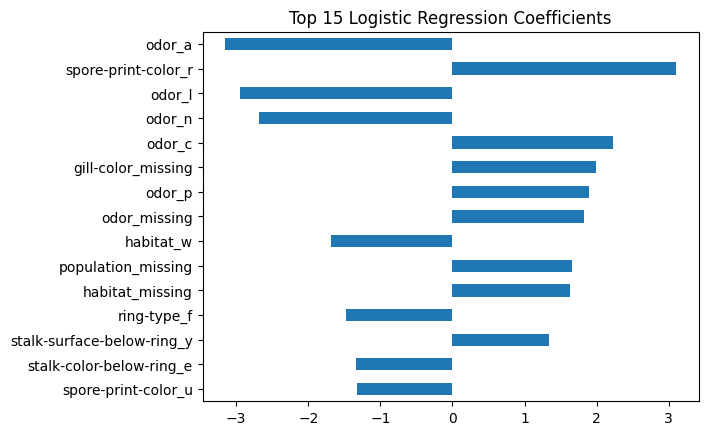

In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train, y_train)

log_coef = pd.Series(
    log_model.coef_[0],
    index=X.columns
).sort_values(key=abs, ascending=False)

plt.figure()
log_coef.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 15 Logistic Regression Coefficients")
plt.show()

As expected, odor is still a very strong indicator of whether a mushroom is poisonous or not. Gill color and spore color still remain when comparing with SVMs but against the Decision Tree model we obtain vastly different features classified as important. However, this model deviates from our initial hypothesis where we expected gill size to be a strong feature. 

Trees capture feature interactions through comparison while SVMs keep features in check to maximize the distance between data and the hyper plane. 

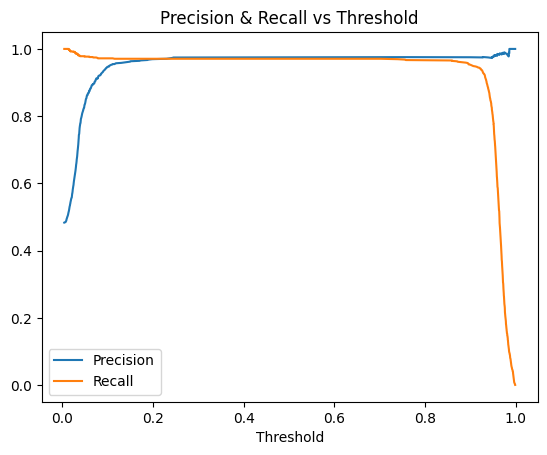

In [ ]:
from sklearn.metrics import precision_recall_curve

log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train, y_train)

y_scores = log_model.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

plt.figure()
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.xlabel("Threshold")
plt.legend()
plt.title("Precision & Recall vs Threshold")
plt.show()

Overall, our precision and recall are not very sensitive to threshold. While precision and recall have a very noticeable rise and fall respectively, these are at thresholds that are not conventionaly good to pick so it is almost expected. Additionally, these rise and falls are very close to gaurantee certain outcomes which hinders our models performance. Mathematically, this also checks out. As we get more positives our recall falls while our precision gets raised. The reason why our precision and threshold are so good for intermediate values of our extremes is simply due to the fact that odor is such a strong feature to classify off of that classification accuracy is almost gauranteed. 

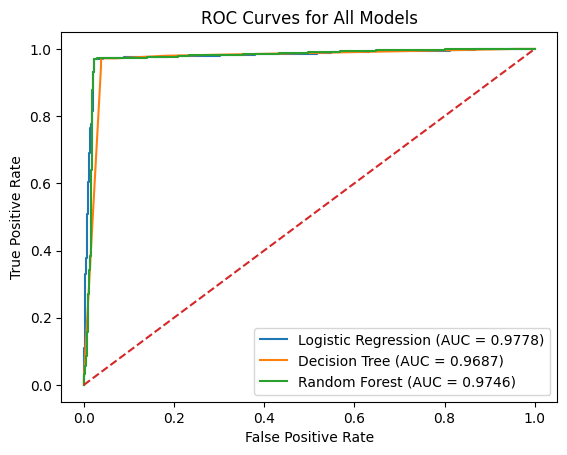

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

models = {
    "Logistic Regression": log_model,
    "Decision Tree": clf,
    "Random Forest": rf
}

plt.figure()

for name, model in models.items():
    
    # Use probability scores for ROC
    if hasattr(model, "predict_proba"):
        y_scores = model.predict_proba(X_test)[:, 1]
    else:
        y_scores = model.decision_function(X_test)
    
    fpr, tpr, _ = roc_curve(y_test, y_scores)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.4f})")

# Diagonal baseline
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for All Models")
plt.legend()
plt.show()

Naturally when comparing ROC curves the model with the highest AUC will be the better model. That being said, any one of the models listed above will work as their AUC are near identical values. Seeing logistic regression have the highest AUC isn't surprising since it captures non-linear relationships between features unlike the other models. 

In [60]:
from sklearn.metrics import accuracy_score

importances = rf.feature_importances_
feature_names = X_train.columns

sorted_indices = np.argsort(importances)[::-1]
top_features = feature_names[sorted_indices[:25]]

print("Top 10 Important Features:")
print(top_features)


X_train_reduced = X_train.drop(columns=top_features)
X_test_reduced = X_test.drop(columns=top_features)

rf_reduced_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf_reduced_model.fit(X_train_reduced, y_train)

y_pred_original = rf.predict(X_test)
y_pred_reduced = rf_reduced_model.predict(X_test_reduced)

acc_original = accuracy_score(y_test, y_pred_original)
acc_reduced = accuracy_score(y_test, y_pred_reduced)

print("\nOriginal Accuracy:", acc_original)
print("Reduced Accuracy:", acc_reduced)
print("Drop in Accuracy:", acc_original - acc_reduced)


# Original model
TP_orig = np.sum((y_pred_original == 1) & (y_test == 1))
FP_orig = np.sum((y_pred_original == 1) & (y_test == 0))
FN_orig = np.sum((y_pred_original == 0) & (y_test == 1))

precision_original = TP_orig / (TP_orig + FP_orig) if (TP_orig + FP_orig) > 0 else 0
recall_original = TP_orig / (TP_orig + FN_orig) if (TP_orig + FN_orig) > 0 else 0


# Reduced model
TP_red = np.sum((y_pred_reduced == 1) & (y_test == 1))
FP_red = np.sum((y_pred_reduced == 1) & (y_test == 0))
FN_red = np.sum((y_pred_reduced == 0) & (y_test == 1))

precision_reduced = TP_red / (TP_red + FP_red) if (TP_red + FP_red) > 0 else 0
recall_reduced = TP_red / (TP_red + FN_red) if (TP_red + FN_red) > 0 else 0


print("\nOriginal Precision:", precision_original)
print("Original Recall:", recall_original)

print("\nReduced Precision:", precision_reduced)
print("Reduced Recall:", recall_reduced)

Top 10 Important Features:
Index(['odor_n', 'gill-size_n', 'odor_f', 'gill-size_b',
       'stalk-surface-above-ring_k', 'stalk-surface-below-ring_k',
       'gill-color_b', 'spore-print-color_h', 'bruises_t', 'ring-type_l',
       'ring-type_p', 'spore-print-color_w', 'bruises_f', 'gill-spacing_w',
       'gill-spacing_c', 'stalk-surface-above-ring_s', 'odor_p',
       'stalk-root_b', 'population_v', 'stalk-surface-below-ring_s',
       'spore-print-color_k', 'stalk-root_e', 'stalk-shape_t',
       'spore-print-color_n', 'stalk-shape_e'],
      dtype='str')

Original Accuracy: 0.9741538461538461
Reduced Accuracy: 0.9538461538461539
Drop in Accuracy: 0.02030769230769225

Original Precision: 0.9757033248081841
Original Recall: 0.9707379134860051

Reduced Precision: 0.9746328437917223
Reduced Recall: 0.9287531806615776


Even after removing our top 10 features we still notice that our accuracy, precision, and recall stay the same. Academically speaking, this is probably due to the fact that the amount of features we produced in our X matrix:

In [52]:
print("Original shape:", X_train.shape)
print("Reduced shape:", X_train_reduced.shape)

Original shape: (6499, 118)
Reduced shape: (6499, 108)


Have multiple redundancies. For example, in earlier graphs we noticed that there were multiple odor classes. Naturally, removing the top 10 wouldn't change our data by that much. However, removing 20 or so features immedietely lowers the quality of our performance. Increasing the amount of features we remove depreciates our performance even further. Big shocker. After testing by margins of 5 features, I noticed that the model depreciates sharper and sharper the more we remove which makes sense as we are literally removing the most important data for classification first. 